<a href="https://colab.research.google.com/github/Cykim0320/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?



1. The main idea is that I make the model "pay" for using large coefficients. If there is no penalty, the model can use very large slopes to fit the training data very closely, even noise. Regularization adds a cost for each unit of coefficient, so the model prefers smaller and simpler coefficients. This helps control model complexity and prevents overfitting.

2. Regularization mainly reduces model variance. When coefficients are smaller, changes in the input variables lead to smaller changes in predictions, so the model becomes more stable. However, shrinking coefficients also adds some bias. When α = 0, I get plain linear regression. As α increases, the model becomes simpler with more bias but less variance. By tuning α, I can control this trade-off and find a balance that gives the best prediction performance.

3. LASSO uses the absolute value penalty, while Ridge uses the squared penalty. Because of this, LASSO can push some coefficients exactly to zero, which means it can remove variables and select a model. Ridge does not set coefficients exactly to zero, but instead smoothly shrinks all coefficients toward zero. So LASSO tends to give sparse solutions with fewer variables, while Ridge keeps all variables but with smaller coefficients. Overall, LASSO is more useful for interpretation, while Ridge often performs better for prediction.

4. I usually z-score normalize numeric variables, meaning I subtract the mean and divide by the standard deviation. This is important because the penalty depends on the size of the coefficients. If variables are on different scales, the penalty will treat them unfairly and distort the results. That is why I normalize numeric variables, but usually not dummy variables, since they are already on a 0/1 scale.

5. The penalty α is chosen using cross-validation. I try different values of α on a grid, fit the model for each one, and evaluate performance on validation data. Then I pick the α that gives the lowest mean or median cross-validated MSE. This way, the data tells me how much to regularize.

6. I do not include the penalty term when evaluating cross-validated MSE. The penalty is only used when fitting the model on the training data. When evaluating performance, I care about how well the model predicts actual outcomes, so I only use the regular MSE. This gives a true measure of predictive performance.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

             Feature       LR_Coef
0        Mileage_Run  6.686165e+05
1                Age -1.841941e+05
2      Mileage_Run^2 -1.494679e+05
3    Mileage_Run Age -1.251592e+06
4              Age^2  2.156399e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  2.833392e+05
7  Mileage_Run Age^2  5.280829e+05
8              Age^3 -1.389370e+05

Mileage_Run x Age interaction: -1251592.3408

Optimal alpha: 5455.5948


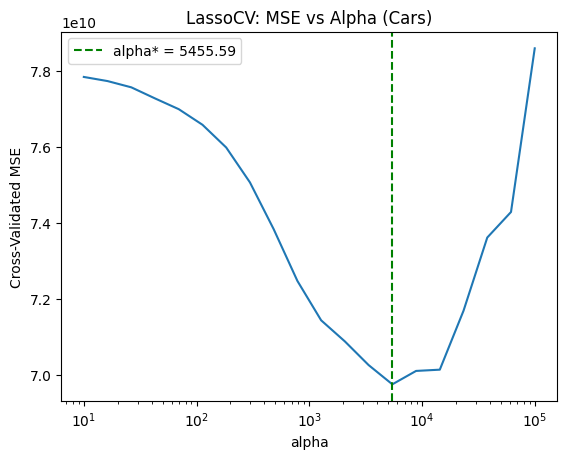

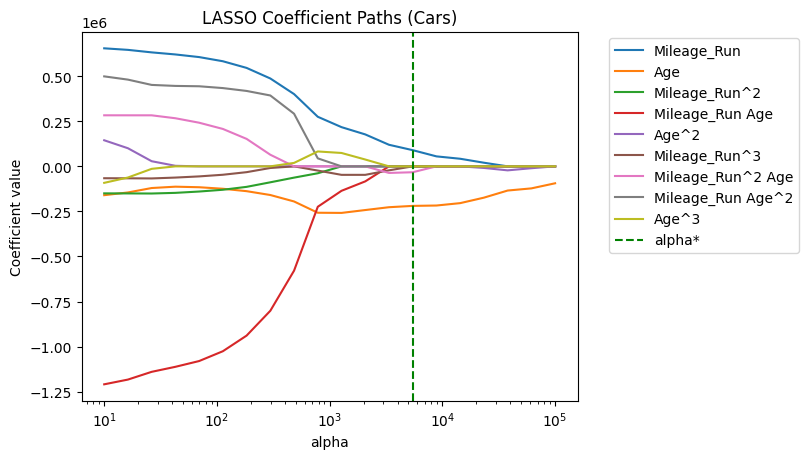


Selected features:
             Feature       LR_Coef     LASSO_Coef
0        Mileage_Run  6.686165e+05  401025.259657
1                Age -1.841941e+05 -194803.116695
2      Mileage_Run^2 -1.494679e+05  -62539.290093
3    Mileage_Run Age -1.251592e+06 -578788.661090
7  Mileage_Run Age^2  5.280829e+05  292015.025679
8              Age^3 -1.389370e+05   19133.908573

Proportion set to zero: 33.33%

Full comparison:
             Feature       LR_Coef     LASSO_Coef  Mag_Increased  Sign_Changed
0        Mileage_Run  6.686165e+05  401025.259657          False         False
1                Age -1.841941e+05 -194803.116695           True         False
2      Mileage_Run^2 -1.494679e+05  -62539.290093          False         False
3    Mileage_Run Age -1.251592e+06 -578788.661090          False         False
4              Age^2  2.156399e+05      -0.000000          False         False
5      Mileage_Run^3 -6.514490e+04      -0.000000          False         False
6  Mileage_Run^2 Age  2.833

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV

df = pd.read_csv('cars_hw.csv')
df['Age'] = 2024 - df['Make_Year']

X_raw = df[['Mileage_Run', 'Age']]
y = df['Price']

# 1.
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# 2.
lr = LinearRegression()
lr.fit(X_scaled, y)

lr_coef = pd.DataFrame({
    'Feature': feature_names,
    'LR_Coef': lr.coef_
})
print(lr_coef)

interaction_idx = list(feature_names).index('Mileage_Run Age')
print(f"\nMileage_Run x Age interaction: {lr.coef_[interaction_idx]:.4f}")

# 3.
alphas = np.logspace(1, 5, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_scaled, y)

index_star = np.argmin(np.median(lasso_cv.mse_path_, axis=1))
alpha_star = lasso_cv.alphas_[index_star]
print(f"\nOptimal alpha: {alpha_star:.4f}")

# 4.
plt.figure()
plt.semilogx(lasso_cv.alphas_, np.median(lasso_cv.mse_path_, axis=1))
plt.axvline(alpha_star, color='green', linestyle='--', label=f'alpha* = {alpha_star:.2f}')
plt.xlabel('alpha')
plt.ylabel('Cross-Validated MSE')
plt.title('LassoCV: MSE vs Alpha (Cars)')
plt.legend()
plt.show()

# 5.
coefs = []
for a in alphas:
    m = Lasso(alpha=a, max_iter=100000)
    m.fit(X_scaled, y)
    coefs.append(m.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature_names[i])
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--', label='alpha*')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths (Cars)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 6.
lasso_coef = pd.DataFrame({
    'Feature': feature_names,
    'LR_Coef': lr.coef_,
    'LASSO_Coef': lasso_cv.coef_
})

selected = lasso_coef[lasso_coef['LASSO_Coef'] != 0]
zero_prop = (lasso_coef['LASSO_Coef'] == 0).mean()

print("\nSelected features:")
print(selected)
print(f"\nProportion set to zero: {zero_prop:.2%}")

# 7.
lasso_coef['Mag_Increased'] = abs(lasso_coef['LASSO_Coef']) > abs(lasso_coef['LR_Coef'])
lasso_coef['Sign_Changed'] = (
    (np.sign(lasso_coef['LASSO_Coef']) != np.sign(lasso_coef['LR_Coef'])) &
    (lasso_coef['LASSO_Coef'] != 0)
)

print("\nFull comparison:")
print(lasso_coef)

1. I imported the cars_hw.csv dataset and created an Age variable by subtracting Make_Year from 2024. I then selected Mileage_Run and Age and applied PolynomialFeatures with degree 3 to generate all polynomial and interaction terms. This resulted in 9 features. Finally, I used StandardScaler to z-score normalize the features before running regression.
2. The interaction term between Mileage_Run and Age is negative (−1,251,592). This means that when both mileage and age increase, the price decreases more sharply. In other words, older cars with higher mileage lose value faster than expected from each variable alone.
3. The optimal alpha selected by 20-fold cross validation is α ≈ 5455.59.
4. The plot shows a clear U-shape. The MSE decreases as α increases from 10, reaches a minimum around α ≈ 5455, and then increases again. This indicates that too little regularization (low α) results in high variance, while too much (high α) over-shrinks the coefficients and increases bias. The optimal α balances bias and variance.
5. As α increases, all coefficients shrink toward zero. The Mileage_Run × Age interaction term shrinks the most dramatically. At the optimal α, several coefficients are exactly zero, while the remaining ones are significantly reduced in magnitude. This shows how LASSO performs feature selection.
6. LASSO selected 6 out of 9 features: Mileage_Run, Age, Mileage_Run², Mileage_Run × Age, Mileage_Run × Age², and Age³. The remaining 3 features (Age², Mileage_Run³, and Mileage_Run² × Age) were set to zero. Therefore, 33.33% of the features were removed by regularization.
7. Age is the only coefficient that increased in magnitude from linear regression to LASSO (−184,194 → −194,803). The coefficient for Age³ also changed sign (−138,937 in linear regression to +19,134 in LASSO). This likely happened because LASSO zeroed out correlated features such as Age² and Mileage_Run³, which changed how the remaining coefficients compensate for the removed terms. All other selected features kept the same sign and decreased in magnitude, which is the expected behavior of LASSO. Overall, this shows that LASSO reduces variance and produces a simpler and more stable model.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

Linear Regression Coefficients:
                                   Feature   LR_Coef
0                                      age  1.539156
1                        ejection_fraction -2.192494
2                         serum_creatinine -0.853588
3                                    age^2 -3.678654
4                    age ejection_fraction -0.600918
5                     age serum_creatinine  1.841563
6                      ejection_fraction^2  3.430976
7       ejection_fraction serum_creatinine  2.673394
8                       serum_creatinine^2 -2.647041
9                                    age^3  1.993135
10                 age^2 ejection_fraction  0.908026
11                  age^2 serum_creatinine -0.697522
12                 age ejection_fraction^2 -0.081206
13  age ejection_fraction serum_creatinine -1.577665
14                  age serum_creatinine^2  1.284099
15                     ejection_fraction^3 -1.250341
16    ejection_fraction^2 serum_creatinine -1.270043
17    ejection

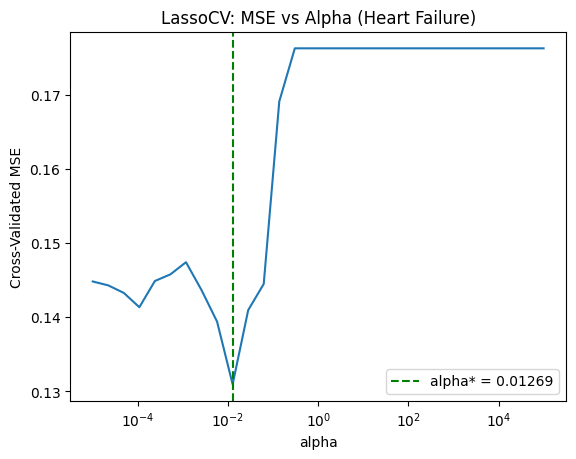

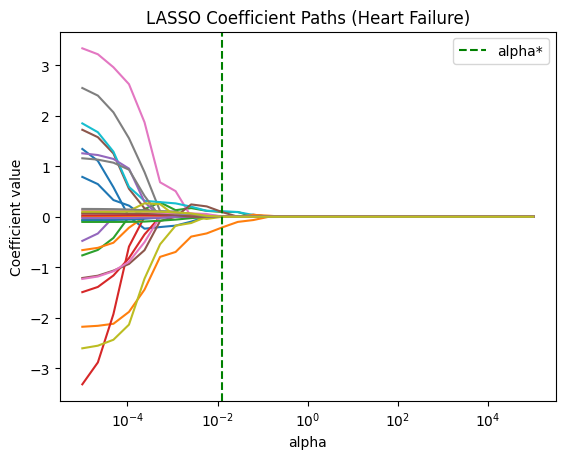


Selected features:
                                 Feature   LR_Coef  LASSO_Coef
1                      ejection_fraction -2.192494   -0.329656
2                       serum_creatinine -0.853588    0.116875
9                                  age^3  1.993135    0.117992
15                   ejection_fraction^3 -1.250341    0.204822
16  ejection_fraction^2 serum_creatinine -1.270043    0.032801
18                    serum_creatinine^3  0.072156   -0.043266
19                               anaemia  0.008093    0.014178
20                              diabetes -0.070705    0.000607
21                   high_blood_pressure -0.007934    0.013608
26          diabetes high_blood_pressure  0.132443    0.053968
27                      diabetes smoking  0.156078    0.003466
28           high_blood_pressure smoking  0.101455    0.017805

Proportion set to zero: 58.62%

Full comparison:
                                   Feature   LR_Coef  LASSO_Coef  Mag_Increased  Sign_Changed
0                

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

# 1.

continuous = df[['age', 'ejection_fraction', 'serum_creatinine']]
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly3.fit_transform(continuous)
cont_names = poly3.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

categorical = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(categorical)
cat_names = poly_cat.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])


X_all = np.hstack([X_cont_scaled, X_cat])
all_names = list(cont_names) + list(cat_names)

y = df['DEATH_EVENT']

# 2.
lr = LinearRegression()
lr.fit(X_all, y)

lr_coef = pd.DataFrame({
    'Feature': all_names,
    'LR_Coef': lr.coef_
})
print("Linear Regression Coefficients:")
print(lr_coef.to_string())

# 3.
alphas = np.logspace(-5, 5, 30)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_all, y)

index_star = np.argmin(np.median(lasso_cv.mse_path_, axis=1))
alpha_star = lasso_cv.alphas_[index_star]
print(f"\nOptimal alpha: {alpha_star:.6f}")

# 4.
plt.figure()
plt.semilogx(lasso_cv.alphas_, np.median(lasso_cv.mse_path_, axis=1))
plt.axvline(alpha_star, color='green', linestyle='--', label=f'alpha* = {alpha_star:.5f}')
plt.xlabel('alpha')
plt.ylabel('Cross-Validated MSE')
plt.title('LassoCV: MSE vs Alpha (Heart Failure)')
plt.legend()
plt.show()

# 5.
coefs = []
for a in alphas:
    m = Lasso(alpha=a, max_iter=100000)
    m.fit(X_all, y)
    coefs.append(m.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--', label='alpha*')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths (Heart Failure)')
plt.legend()
plt.show()

# 6.
lasso_coef = pd.DataFrame({
    'Feature': all_names,
    'LR_Coef': lr.coef_,
    'LASSO_Coef': lasso_cv.coef_
})

selected = lasso_coef[lasso_coef['LASSO_Coef'] != 0]
zero_prop = (lasso_coef['LASSO_Coef'] == 0).mean()

print("\nSelected features:")
print(selected.to_string())
print(f"\nProportion set to zero: {zero_prop:.2%}")

lasso_coef['Mag_Increased'] = abs(lasso_coef['LASSO_Coef']) > abs(lasso_coef['LR_Coef'])
lasso_coef['Sign_Changed'] = (
    (np.sign(lasso_coef['LASSO_Coef']) != np.sign(lasso_coef['LR_Coef'])) &
    (lasso_coef['LASSO_Coef'] != 0)
)

print("\nFull comparison:")
print(lasso_coef.to_string())

1. I imported the heart_failure_clinical_records_dataset.csv dataset. For the continuous variables age, ejection_fraction, and serum_creatinine, I applied PolynomialFeatures with degree=3 to generate all polynomial and interaction terms, then used StandardScaler to z-score normalize the results. For the categorical variables anaemia, diabetes, high_blood_pressure, and smoking, I applied PolynomialFeatures with interaction_only=True to create interaction terms only. I then concatenated both sets of features into a single feature matrix, resulting in 29 total features.

2. Several sign patterns look counterintuitive in the linear regression results. For example, ejection_fraction has a negative coefficient, which makes sense clinically since lower ejection fraction is associated with higher death risk. However, ejection_fraction² is large and positive, and ejection_fraction³ is negative again. These alternating signs are not clinically meaningful on their own. This happens because the polynomial terms are highly correlated with each other, so OLS distributes the coefficients arbitrarily across them to minimize training error. The higher-order terms and interactions can resolve this apparent contradiction because together they capture the true nonlinear relationship, even if each individual coefficient looks strange.

3. The optimal alpha I selected using 20-fold cross validation is α ≈ 0.01269.

4. The MSE plot shows a clear minimum around α ≈ 0.01269. At very low alpha values the MSE is relatively high due to high variance. As alpha increases toward the optimal point, MSE decreases. After the optimal point, MSE rises sharply as the model becomes too simple and underfits the data.

5. At very low alpha values, many coefficients are large and unstable, reflecting the high variance of the unregularized model. As alpha increases, coefficients shrink toward zero. Most of them reach zero well before the optimal alpha, and only a small number of coefficients survive at alpha*.

6. LASSO selected 12 out of 29 features, setting 58.62% of coefficients to zero. The selected features include ejection_fraction, serum_creatinine, age³, ejection_fraction³, ejection_fraction² × serum_creatinine, serum_creatinine³, and several categorical variables.
Several coefficients increased in magnitude from linear regression to LASSO: anaemia (0.008 → 0.014) and high_blood_pressure (−0.008 → 0.014). Several coefficients also changed sign: serum_creatinine, ejection_fraction³, ejection_fraction² × serum_creatinine, serum_creatinine³, diabetes, and high_blood_pressure.
The LASSO sign patterns make more clinical sense. Higher serum_creatinine is a known risk factor for death, so a positive coefficient is more interpretable. The linear regression coefficients are unstable because of multicollinearity between the polynomial terms, which causes large and arbitrary coefficient values. This is a classic high-variance problem. LASSO reduces variance by shrinking and zeroing out most coefficients, accepting some bias in return. The result is a simpler and more stable model whose coefficients are easier to interpret and more consistent with clinical knowledge.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?



**1. Objective function for Ridge regression**

I add the penalty αb₁² to the mean squared error. The objective function is:

L(b₀, b₁) = (1/n) Σᵢ(ỹᵢ - b₀ - b₁x̃ᵢ)² + αb₁²

**2. Derivatives and solution**

Taking the derivative with respect to b₀ and setting it to zero:

∂L/∂b₀ = -(2/n) Σᵢ(ỹᵢ - b₀ - b₁x̃ᵢ) = 0

Since the data is mean-normalized, Σỹᵢ = 0 and Σx̃ᵢ = 0, so:

b₀ = 0

Taking the derivative with respect to b₁ and setting it to zero:

∂L/∂b₁ = -(2/n) Σᵢ x̃ᵢ(ỹᵢ - b₁x̃ᵢ) + 2αb₁ = 0

Solving for b₁:

b₁ = [(1/n) Σ x̃ᵢỹᵢ] / [(1/n) Σ x̃ᵢ² + α]

When α = 0, this reduces to the standard OLS estimate.

**3. Effect of increasing α**

As α increases, the denominator becomes larger while the numerator stays the same. Therefore, b₁ shrinks toward zero. This reduces the slope and makes the model less sensitive to changes in x, which lowers variance.

**4. LASSO/L1 penalty challenge**

The LASSO objective function is:

L(b₀, b₁) = (1/n) Σᵢ(ỹᵢ - b₀ - b₁x̃ᵢ)² + α|b₁|

The challenge is that |b₁| is not differentiable at b₁ = 0. Therefore, I cannot solve this problem using standard derivatives as in ridge regression.

Instead, I consider subgradients. The subgradient of |b₁| is sign(b₁) when b₁ ≠ 0, and any value in [−1, 1] when b₁ = 0.

Using this idea, I can determine when it is optimal to set b₁ = 0. If the relationship between x and y is not strong enough to overcome the penalty α, then the optimal solution is b₁ = 0.

This is why LASSO produces exact zeros while ridge regression does not. The L1 penalty creates a "corner" at zero, making it optimal for coefficients to be exactly zero when the signal is weak.